# Heavy-Ball Method and Polyak Momentum

The **heavy-ball method** (Polyak 1964) adds inertia to gradient descent:
$$
x^{k+1} = x^k - \tau \nabla f(x^k) + \beta(x^k - x^{k-1}),
$$
where $\tau > 0$ is the step size and $\beta \in [0,1)$ is the **momentum coefficient**.

## Optimal parameters for strongly convex quadratics

For $f(x) = \frac{1}{2}x^\top A x$ with $A = Q\Lambda Q^\top$, $\lambda_{\min} = \mu$, $\lambda_{\max} = L$, the optimal parameters are:
$$
\tau^* = \frac{4}{(\sqrt{L}+\sqrt{\mu})^2}, \qquad \beta^* = \left(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\right)^2,
$$
giving the **optimal linear rate** $\rho^* = \left(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\right)$ (vs. $(\kappa-1)/(\kappa+1)$ for GD).

## Stability analysis

The heavy-ball update can be written as a 2D linear iteration $z^{k+1} = M z^k$ where $z^k = (x^k - x^*, x^{k-1} - x^*)$:
$$
M = \begin{pmatrix} (1+\beta)I - \tau A & -\beta I \\ I & 0 \end{pmatrix}.
$$
Convergence requires $\rho(M) < 1$. The spectral radius depends on $\tau$ and $\beta$.

## Beyond quadratics

For general non-convex functions, the heavy-ball method may **not converge** — it can cycle. Nesterov's method provides convergence guarantees for general convex functions.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

plt.rcParams['figure.dpi'] = 120

## Spectral radius as a function of ($\tau$, $\beta$)

We compute the spectral radius of the iteration matrix $M$ and show which $(\tau, \beta)$ pairs converge.

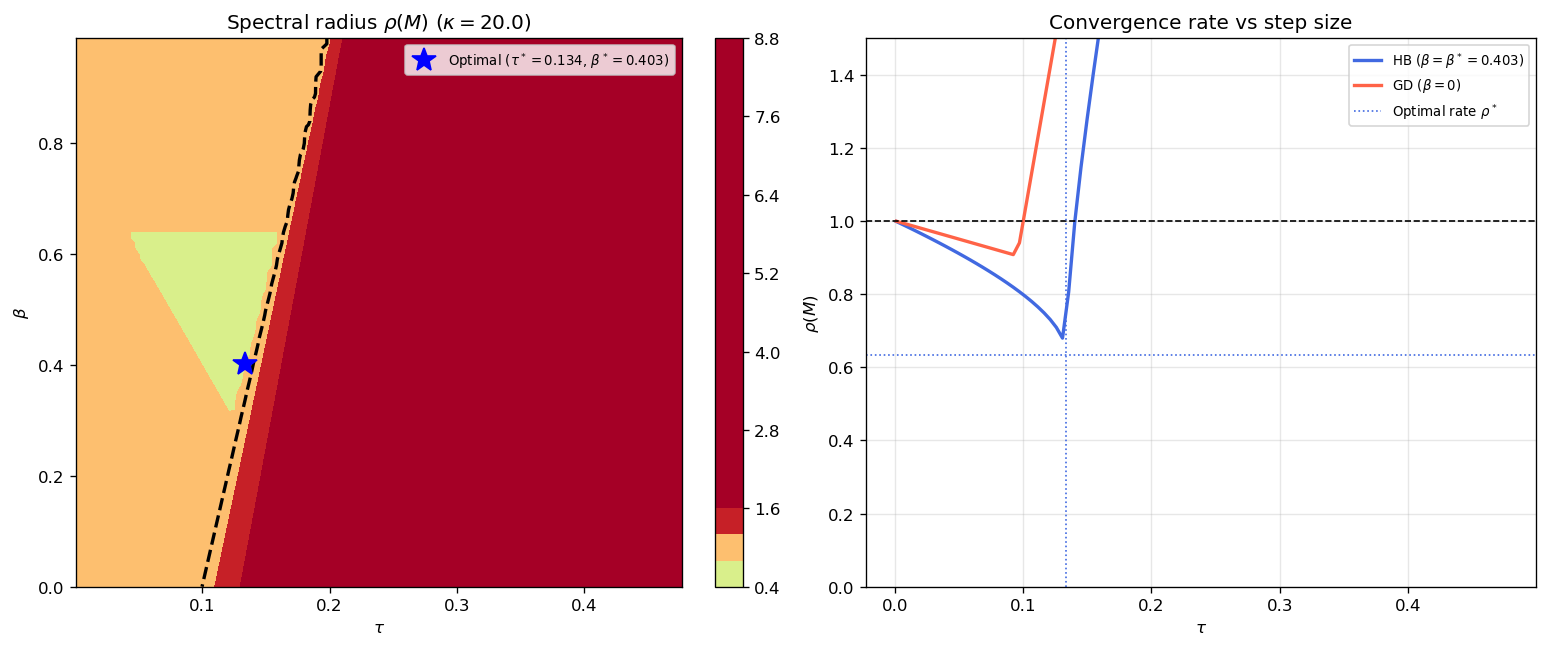

In [2]:
mu, L = 1.0, 20.0
kappa = L / mu

tau_grid = np.linspace(0.001, 4/(mu+L)*2.5, 100)
beta_grid = np.linspace(0, 0.99, 100)
Tau, Beta = np.meshgrid(tau_grid, beta_grid)

# For each lambda in {mu, L}, spectral radius of the 2x2 block
# M_lambda = [[1+beta-tau*lambda, -beta], [1, 0]]
def block_rho(lam, tau, beta):
    a = 1 + beta - tau * lam
    # char poly: x^2 - a*x + beta = 0
    disc = a**2 - 4*beta
    if disc >= 0:
        r1, r2 = (a + np.sqrt(disc))/2, (a - np.sqrt(disc))/2
        return max(abs(r1), abs(r2))
    else:
        return np.sqrt(beta)

vblock_rho = np.vectorize(block_rho)
rho_mu = vblock_rho(mu, Tau, Beta)
rho_L  = vblock_rho(L,  Tau, Beta)
rho_max = np.maximum(rho_mu, rho_L)

# Optimal params
tau_opt = 4 / (np.sqrt(L) + np.sqrt(mu))**2
beta_opt = ((np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1))**2

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
im = axes[0].contourf(tau_grid, beta_grid, rho_max, levels=20, cmap='RdYlGn_r', vmin=0, vmax=1.5)
axes[0].contour(tau_grid, beta_grid, rho_max, levels=[1.0], colors='k', linewidths=2, linestyles='--')
axes[0].plot(tau_opt, beta_opt, 'b*', ms=15, label=f'Optimal ($\\tau^*={tau_opt:.3f}$, $\\beta^*={beta_opt:.3f}$)')
plt.colorbar(im, ax=axes[0], fraction=0.046)
axes[0].set_xlabel('$\\tau$'); axes[0].set_ylabel('$\\beta$')
axes[0].set_title(f'Spectral radius $\\rho(M)$ ($\\kappa={kappa}$)')
axes[0].legend(fontsize=8)

# Convergence rates along optimal beta
tau_range = tau_grid
rho_opt_beta = np.array([max(vblock_rho(mu, t, beta_opt), vblock_rho(L, t, beta_opt)) for t in tau_range])
rho_gd = np.array([max(abs(1-t*mu), abs(1-t*L)) for t in tau_range])
axes[1].plot(tau_range, rho_opt_beta, 'royalblue', lw=2, label=f'HB ($\\beta=\\beta^*={beta_opt:.3f}$)')
axes[1].plot(tau_range, rho_gd, 'tomato', lw=2, label='GD ($\\beta=0$)')
axes[1].axhline(1.0, color='k', ls='--', lw=1)
axes[1].axhline((np.sqrt(kappa)-1)/(np.sqrt(kappa)+1), color='royalblue', ls=':', lw=1, label=f'Optimal rate $\\rho^*$')
axes[1].axvline(tau_opt, color='royalblue', ls=':', lw=1)
axes[1].set_ylim(0, 1.5)
axes[1].set_xlabel('$\\tau$'); axes[1].set_ylabel('$\\rho(M)$')
axes[1].set_title('Convergence rate vs step size'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Non-convex: cycling behaviour

For the **Rosenbrock function**, the optimal heavy-ball parameters for the local quadratic approximation near the minimum can cause oscillations globally.

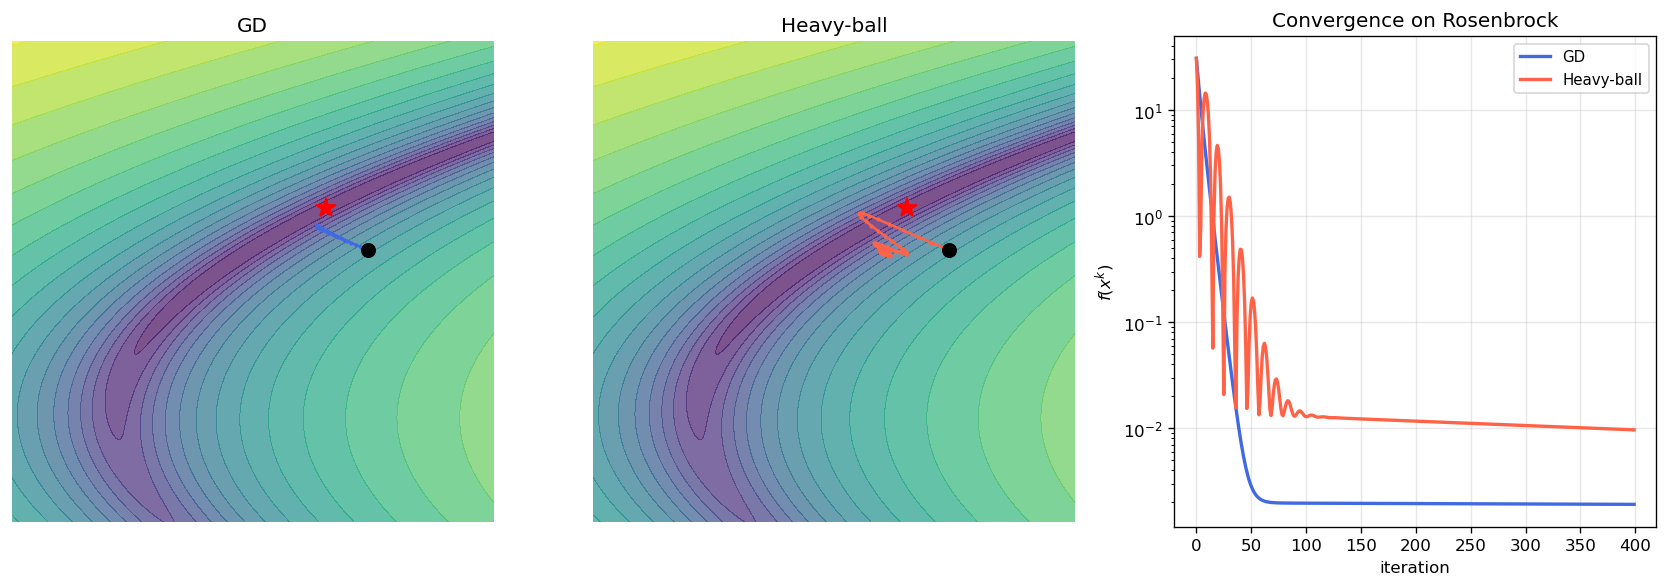

In [3]:
def rosenbrock(x, y):
    return (1-x)**2 + 100*(y-x**2)**2
def rosenbrock_grad(x, y):
    return np.array([-2*(1-x) - 400*x*(y-x**2), 200*(y-x**2)])

def heavy_ball(f_grad, x0, tau, beta, n_iter):
    x = x0.copy(); x_prev = x.copy(); traj = [x.copy()]; fvals = []
    for _ in range(n_iter):
        g = f_grad(*x)
        x_new = x - tau*g + beta*(x - x_prev)
        x_prev, x = x, x_new
        traj.append(x.copy())
        fvals.append(rosenbrock(*x))
    return np.array(traj), np.array(fvals)

tau_val = 1e-4; beta_val = 0.9
traj_hb, fvals_hb = heavy_ball(rosenbrock_grad, np.array([1.2, 0.8]), tau_val, beta_val, 400)
traj_gd, fvals_gd = heavy_ball(rosenbrock_grad, np.array([1.2, 0.8]), tau_val, 0.0, 400)

x_r = np.linspace(-0.5, 1.8, 200); y_r = np.linspace(-0.5, 1.8, 200)
Xr, Yr = np.meshgrid(x_r, y_r)
Fr = rosenbrock(Xr, Yr)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (t, label, col) in zip(axes[:2], [(traj_gd, 'GD', 'royalblue'), (traj_hb, 'Heavy-ball', 'tomato')]):
    ax.contourf(x_r, y_r, np.log1p(Fr).T, levels=20, cmap='viridis', alpha=0.7)
    ax.plot(t[:,0], t[:,1], '.-', lw=1.5, ms=3, color=col)
    ax.plot(t[0,0], t[0,1], 'ko', ms=8)
    ax.plot(1, 1, 'r*', ms=12)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(label)

axes[2].semilogy(fvals_gd, 'royalblue', lw=2, label='GD')
axes[2].semilogy(fvals_hb, 'tomato',    lw=2, label='Heavy-ball')
axes[2].set_xlabel('iteration'); axes[2].set_ylabel('$f(x^k)$')
axes[2].set_title('Convergence on Rosenbrock'); axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Interactive: momentum coefficient

In [4]:
def show_hb(tau=1e-4, beta=0.9, n_iter=400):
    t_i, f_i = heavy_ball(rosenbrock_grad, np.array([1.2, 0.8]), tau, beta, n_iter)
    t_g, f_g = heavy_ball(rosenbrock_grad, np.array([1.2, 0.8]), tau, 0.0, n_iter)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].contourf(x_r, y_r, np.log1p(Fr).T, levels=20, cmap='viridis', alpha=0.7)
    axes[0].plot(t_i[:,0], t_i[:,1], '.-', lw=1.5, ms=2, color='tomato', label=f'HB $\\beta={beta}$')
    axes[0].plot(t_g[:,0], t_g[:,1], '.-', lw=1.5, ms=2, color='white', label='GD', alpha=0.5)
    axes[0].plot(1.2, 0.8, 'ko', ms=8); axes[0].plot(1,1,'r*',ms=12)
    axes[0].set_aspect('equal'); axes[0].axis('off'); axes[0].legend(fontsize=8)
    axes[0].set_title(f'Trajectories ($\\tau={tau:.1e}$, $\\beta={beta}$)')
    axes[1].semilogy(f_g, 'royalblue', lw=2, label='GD')
    axes[1].semilogy(f_i, 'tomato', lw=2, label=f'HB $\\beta={beta}$')
    axes[1].set_xlabel('iteration'); axes[1].set_ylabel('$f$'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_hb,
         tau=FloatSlider(value=1e-4, min=1e-5, max=5e-4, step=1e-5, readout_format='.1e', description='$\\tau$'),
         beta=FloatSlider(value=0.9, min=0.0, max=0.99, step=0.05, description='$\\beta$'),
         n_iter=IntSlider(value=400, min=100, max=1000, step=100, description='iters'));

interactive(children=(FloatSlider(value=0.0001, description='$\\tau$', max=0.0005, min=1e-05, readout_format='…

## Bibliographical resources

- Polyak, B. T. (1964). Some methods of speeding up the convergence of iteration methods. *USSR Computational Mathematics and Mathematical Physics*, 4(5), 1–17.
- Ghadimi, E., Feyzmahdavian, H. R. and Johansson, M. (2015). Global convergence of the heavy-ball method for convex optimization. *European Control Conference*, 310–315.
- Lessard, L., Recht, B. and Packard, A. (2016). Analysis and design of optimization algorithms via integral quadratic constraints. *SIAM Journal on Optimization*, 26(1), 57–95.
- Sebbouh, O., Gower, R. M. and Defazio, A. (2021). Almost sure convergence of dropout algorithms for neural networks. *NeurIPS*.
- Nesterov, Y. (2004). *Introductory Lectures on Stochastic Optimization*. Kluwer.